In [1]:
# --- 1. POSTAVKE SUSTAVA (Globalne varijable) ---
set.seed(42)
N_SIMS              <- 50000
INIT_PTS            <- 120
N_CARDS_DRAWN       <- 5 # was 10
SUITS               <- 4
CARDS_PER_SUIT      <- 10
START_BANKROLL      <- 1000
DPI                 <- 300

# --- 1b. TUNABLE PARAMETRI STRATEGIJA ---
FLAT_BET            <- 10       # Osnovni ulog za Flat/Martingale/Anti-Martingale strategiju
KELLY_FRACTION      <- 0.05     # Kelly kriterij: udio bankrolla po rundi (5%)
MAX_BET             <- 500      # Gornji limit uloga za Martingale i Anti-Martingale progresiju
N_LIMIT             <- 20       # Broj rundi za analizu ograničenog vremenskog horizonta
LIMIT_STEPS         <- seq(10, 100, by = 10)  # Koraci analize limita rundi za casino optimizaciju
N_CASINO_REPS       <- 500      # Broj replikacija po koraku u casino optimizaciji
N_RISK_REPS         <- 500      # Broj replikacija u stress testu rizika
BIG_WIN_THRESHOLD   <- 0.5     # Prag "velikog dobitka" igrača (udio početnog bankrolla)

deck_suits <- rep(1:SUITS, each = CARDS_PER_SUIT)

print("test")

[1] "test"


In [2]:
# --- 2. LOGIKA MODELA (Računalni model) ---

#' @title Računalna simulacija jedne runde igre
#' @description Izvodi stohastički proces miješanja špila i izvlačenja uzorka karata.
#' @param bet Numerička vrijednost uloga u trenutnoj rundi.
#' @return Lista s rezultatima: broj pogodaka (hits), ostvareni neto profit i faktor isplate.
#' @section Logika:
#' Koristi diskretnu uniformnu distribuciju za odabir aduta i bez-ponavljajuće
#' uzorkovanje (sampling without replacement) za simulaciju fizičkog špila.
play_round <- function(bet) {
  briscola_suit <- sample(1:SUITS, 1)
  shuffled      <- sample(deck_suits)
  hand          <- shuffled[1:N_CARDS_DRAWN]

  hits     <- sum(hand == briscola_suit)
  misses   <- N_CARDS_DRAWN - hits

  pts      <- INIT_PTS + hits * 10 - misses * 10
  mult     <- pts / INIT_PTS
  profit   <- (mult - 1) * bet

  return(list(hits = hits, profit = profit, mult = mult))
}

In [3]:
# --- 3. SIMULACIJA STRATEGIJA (Monte Carlo Engine) ---

#' @title Iterativni Monte Carlo simulator strategija
#' @description Simulira dugoročno kretanje kapitala kroz 10^5 iteracija koristeći različite modalitete klađenja.
#' @param strategy_name Identifikator taktike (Flat, Martingale, Anti-Martingale, Kelly).
#' @param n_sims Ukupan broj runda u simulaciji.
#' @param flat_bet Osnovni ulog za fiksne i progresivne sustave.
#' @return Detaljan vremenski niz bankrolla, uloga i ishoda runda.
simulate_strategy <- function(strategy_name, n_sims = N_SIMS, flat_bet = FLAT_BET) {
  bankroll    <- numeric(n_sims + 1)
  net_profit  <- numeric(n_sims)
  hits_vec    <- numeric(n_sims)
  bets_vec    <- numeric(n_sims)

  bankroll[1] <- START_BANKROLL
  current_bet <- flat_bet

  for (i in seq_len(n_sims)) {
    bet <- switch(strategy_name,
                  "Flat"           = flat_bet,
                  "Martingale"     = current_bet,
                  "Anti-Martingale"= current_bet,
                  "Kelly"          = max(1, bankroll[i] * KELLY_FRACTION))

    bet <- min(bet, bankroll[i])
    bets_vec[i] <- bet

    if (bankroll[i] <= 0) { bankroll[(i+1):(n_sims+1)] <- 0; break }

    res <- play_round(bet)

    bankroll[i+1]  <- bankroll[i] + res$profit
    net_profit[i]  <- res$profit
    hits_vec[i]    <- res$hits

    if (strategy_name == "Martingale") {
      current_bet <- if (res$profit < 0) min(current_bet * 2, MAX_BET) else flat_bet
    } else if (strategy_name == "Anti-Martingale") {
      current_bet <- if (res$profit > 0) min(current_bet * 2, MAX_BET) else flat_bet
    }
  }

  return(list(name = strategy_name, bank = bankroll, prof = net_profit,
              hits = hits_vec, bets = bets_vec))
}


In [4]:
# --- 4. IZVRŠAVANJE I ANALIZA ---
print("test")
strategies <- c("Flat", "Martingale", "Anti-Martingale", "Kelly")
results    <- lapply(strategies, simulate_strategy)
names(results) <- strategies

strategies

[1] "test"


[1] "Flat"            "Martingale"      "Anti-Martingale" "Kelly"

In [5]:
# --- 5. TABLIČNI ISPIS KRETANJA FINANCIJA I STATUS BANKROTA ---

cat("\n==============================================================================\n")
cat("   DETALJAN PREGLED TIJEKA IGRE I ANALIZA PREŽIVLJAVANJA   \n")
cat("==============================================================================\n")

for (strat in strategies) {
  cat(sprintf("\n--- STRATEGIJA: %s ---\n", strat))

  bankruptcy_round <- which(results[[strat]]$bank <= 0)[1] - 1

  play_log <- data.frame(
    Runda     = 1:10,
    Ulog      = results[[strat]]$bets[1:10],
    Pogoci    = results[[strat]]$hits[1:10],
    Neto_Rez  = round(results[[strat]]$prof[1:10], 2),
    Bankroll  = round(results[[strat]]$bank[2:11], 2)
  )

  play_log$Ishod <- ifelse(play_log$Neto_Rez > 0, "DOBITAK",
                           ifelse(play_log$Neto_Rez < 0, "GUBITAK", "NULA"))

  print(play_log, row.names = FALSE)

  if (!is.na(bankruptcy_round)) {
    cat(sprintf("!!! BANKROT: Igrač je izgubio sav novac u %d. rundi !!!\n", bankruptcy_round))
  } else {
    cat(sprintf("STATUS: Igrač je preživio svih %d runda.\n", N_SIMS))
  }
}


   DETALJAN PREGLED TIJEKA IGRE I ANALIZA PREŽIVLJAVANJA   

--- STRATEGIJA: Flat ---
 Runda Ulog Pogoci Neto_Rez Bankroll   Ishod
     1   10      2    -0.83   999.17 GUBITAK
     2   10      1    -2.50   996.67 GUBITAK
     3   10      1    -2.50   994.17 GUBITAK
     4   10      1    -2.50   991.67 GUBITAK
     5   10      0    -4.17   987.50 GUBITAK
     6   10      0    -4.17   983.33 GUBITAK
     7   10      2    -0.83   982.50 GUBITAK
     8   10      2    -0.83   981.67 GUBITAK
     9   10      2    -0.83   980.83 GUBITAK
    10   10      2    -0.83   980.00 GUBITAK
STATUS: Igrač je preživio svih 50000 runda.

--- STRATEGIJA: Martingale ---
 Runda Ulog Pogoci Neto_Rez Bankroll   Ishod
     1   10      1    -2.50   997.50 GUBITAK
     2   20      0    -8.33   989.17 GUBITAK
     3   40      1   -10.00   979.17 GUBITAK
     4   80      3     6.67   985.83 DOBITAK
     5   10      3     0.83   986.67 DOBITAK
     6   10      0    -4.17   982.50 GUBITAK
     7   20      0    -8.33

In [6]:
# --- 6. STATISTIČKA VALIDACIJA I VIZUALIZACIJA ---

#' @title Analitička verifikacija modela
#' @description Izračun teorijskog očekivanja pomoću Hipergeometrijske distribucije.
#' Očekivani broj pogodaka E(X) = n * (K/N) = 10 * (10/40) = 2.5.
expected_mult <- (120 + 2.5 * 10 - 7.5 * 10) / 120
rtp_val       <- expected_mult * 100

print(expected_mult)

cat("\n========================================================\n")
cat(sprintf("KONAČNI REZULTAT: Teorijski RTP: %.2f%% | House Edge: %.2f%%\n", rtp_val, 100 - rtp_val))
cat("========================================================\n")

tiff("01_Analiza_Modela_300dpi.tiff", width=2400, height=1800, res=DPI)
par(mfrow = c(1, 2))
h_counts <- table(factor(results$Flat$hits, levels=0:10))
h_dist   <- h_counts / sum(h_counts)
theory   <- dhyper(0:10, 10, 30, 10)
b <- barplot(h_dist, main="Distribucija aduta (Simulacija vs Teorija)", col="#4C72B0", xlab="Pogoci", ylab="Vjerojatnost")
lines(x = b, y = theory, type="b", pch=18, col="red", lwd=2)
dev.off()

cat("\n✓ Svi izvještaji i tablice su generirani.\n")

cat("test")

[1] 0.5833333

KONAČNI REZULTAT: Teorijski RTP: 58.33% | House Edge: 41.67%


agg_record_17977fbf37fa 
                      2


✓ Svi izvještaji i tablice su generirani.
test

In [8]:
# --- 7. ANALIZA EKSTREMNIH DOGAĐAJA ---

#' @title Analiza ekstremnih ishoda: Mitski "10 od 10" scenarij
#' @description
#' Dok model simulira N_SIMS iteracija, postoji teorijski ishod maksimalnog dobitka
#' gdje igrač izvlači svih 10 briškula (aduta) iz špila.
#'
#' @details
#' Vjerojatnost ovog događaja računa se hipergeometrijskom distribucijom:
#' P(X=10) = (10 choose 10) / (40 choose 10) = 1 / 847,660,528.
#' S obzirom na vjerojatnost od ~1 u 847 milijuna, u simulaciji od 100,000 runda
#' očekivani broj pojavljivanja ovog ishoda je statistički zanemariv (crni labud).

theoretical_p <- 1 / choose(40, 10)
actual_count <- sum(results$Flat$hits == 10)

cat("\n--- ANALIZA EKSTREMNOG DOGAĐAJA (10/10 Briškula) ---\n")
cat(sprintf("Vjerojatnost:          1 u %.0f milijuna\n", (1/theoretical_p) / 1e6))
cat(sprintf("Pojavljivanja u tvojih %.0f simulacija: %d\n", N_SIMS, actual_count))

if(actual_count == 0) {
  cat("Zaključak: Statistički 'crni labud' nije detektiran u uzorku.\n")
}

ideal_pts     <- 120 + (10 * 10) - (0 * 10)
ideal_mult    <- ideal_pts / 120
ideal_profit  <- (ideal_mult - 1) * 1000

cat(sprintf("\nU slučaju 'Best Case' scenarija (ulog 1000€):\n"))
cat(sprintf("Završni bodovi:        %d\n", ideal_pts))
cat(sprintf("Isplatni faktor:       %.3fx\n", ideal_mult))
cat(sprintf("Neto dobitak:          +%.2f€\n", ideal_profit))


--- ANALIZA EKSTREMNOG DOGAĐAJA (10/10 Briškula) ---
Vjerojatnost:          1 u 848 milijuna
Pojavljivanja u tvojih 50000 simulacija: 0
Zaključak: Statistički 'crni labud' nije detektiran u uzorku.

U slučaju 'Best Case' scenarija (ulog 1000€):
Završni bodovi:        220
Isplatni faktor:       1.833x
Neto dobitak:          +833.33€


In [9]:
# --- 8. ZBIRNA STATISTIKA (Risk Assessment) ---

cat("\n========================================================\n")
cat("          USPOREDNA STATISTIKA IZDRŽLJIVOSTI           \n")
cat("========================================================\n")

summary_stats <- data.frame(
  Strategija = strategies,
  Preživljeno_Runda = sapply(strategies, function(s) {
    idx <- which(results[[s]]$bank <= 0)[1] - 1
    if(is.na(idx)) N_SIMS else idx
  }),
  Konačni_Bankroll = sapply(strategies, function(s) round(tail(results[[s]]$bank, 1), 2))
)

summary_stats$Status <- ifelse(summary_stats$Preživljeno_Runda < N_SIMS, "BANKROTIRAO", "PREŽIVIO")

print(summary_stats, row.names = FALSE)


          USPOREDNA STATISTIKA IZDRŽLJIVOSTI           
      Strategija Preživljeno_Runda Konačni_Bankroll   Status
            Flat             50000                0 PREŽIVIO
      Martingale             50000                0 PREŽIVIO
 Anti-Martingale             50000                0 PREŽIVIO
           Kelly             50000                0 PREŽIVIO


In [10]:
# --- 9. OGRANIČENA SIMULACIJA (Limit: N_LIMIT Runda) ---

#' @title Simulacija s fiksnim vremenskim horizontom
#' @description Simulira što se događa ako igrač odluči stati nakon točno N_LIMIT runda,
#' što je čest scenarij u stvarnom svijetu (ograničeno vrijeme/strpljenje).

cat("\n========================================================\n")
cat(sprintf("   ANALIZA ISHODA NAKON LIMITA OD %d RUNDA   \n", N_LIMIT))
cat("========================================================\n")

results_limit <- lapply(strategies, function(s) simulate_strategy(s, n_sims = N_LIMIT))
names(results_limit) <- strategies

print(strategies)

summary_limit <- data.frame(
  Strategija = strategies,
  Početni_Bankroll = START_BANKROLL,
  Konačni_Bankroll = sapply(strategies, function(s) round(tail(results_limit[[s]]$bank, 1), 2))
)

summary_limit$Neto_Profit <- summary_limit$Konačni_Bankroll - summary_limit$Početni_Bankroll
summary_limit$Ishod <- ifelse(summary_limit$Neto_Profit > 0, "PROFIT", "GUBITAK")

print(summary_limit, row.names = FALSE)

dev.new()
par(mfrow = c(1, 1))
plot(results_limit$Flat$bank, type="l", col="blue", lwd=2, ylim=c(500, 1500),
     main=sprintf("Kretanje kapitala kroz %d runda", N_LIMIT),
     xlab="Runda", ylab="Bankroll (€)")
lines(results_limit$Martingale$bank, col="red", lwd=2)
lines(results_limit$Kelly$bank, col="green", lwd=2)
lines(results_limit$Anti_Martingale$bank, col="orange", lwd=2)
abline(h=START_BANKROLL, lty=2)
legend("topleft", legend=strategies, col=c("blue", "red", "orange", "green"), lwd=2)

cat("\n✓ Analiza limita je gotova. Primijeti razliku u 'preživljavanju'!\n")



   ANALIZA ISHODA NAKON LIMITA OD 20 RUNDA   
[1] "Flat"            "Martingale"      "Anti-Martingale" "Kelly"          
      Strategija Početni_Bankroll Konačni_Bankroll Neto_Profit   Ishod
            Flat             1000           968.33      -31.67 GUBITAK
      Martingale             1000            74.22     -925.78 GUBITAK
 Anti-Martingale             1000           959.17      -40.83 GUBITAK
           Kelly             1000           803.87     -196.13 GUBITAK

✓ Analiza limita je gotova. Primijeti razliku u 'preživljavanju'!



Pokrećem simulaciju limita...
 Maks_Rundi   Flat Martingale  Kelly Anti_Mart
         10  20.69     361.19  98.63     22.92
         20  41.33     743.22 188.52     46.02
         30  62.39     921.50 266.16     68.89
         40  83.35     984.17 339.18     91.80
         50 103.84     993.57 409.72    115.69
         60 125.09     997.92 466.69    138.44
         70 145.41     999.96 516.06    161.03
         80 166.91     999.98 568.50    185.46
         90 187.84    1000.00 610.36    207.54
        100 207.88    1000.00 649.25    229.60

ZAKLJUČAK ZA UPRAVU CASINA:
- Ako dozvolite 100 rundi, prosječan igrač na Flat-u će vam ostaviti 207.88€.
- Martingale igrači su najisplativiji; prosječno gube 1000.00€ u 100 rundi.


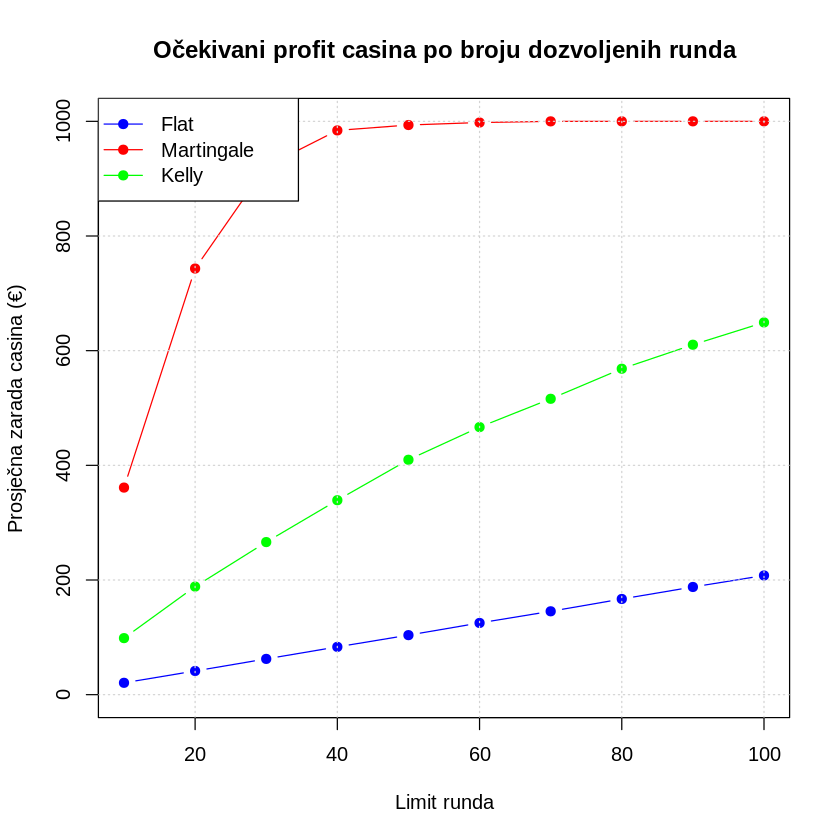

In [11]:
# --- 10. CASINO OPTIMIZACIJA: ANALIZA LIMITA RUNDI (Ispravljena verzija) ---

casino_izvjestaj <- data.frame()

cat("\nPokrećem simulaciju limita...\n")

for (limit in LIMIT_STEPS) {

  avg_profits <- sapply(strategies, function(s) {
    runs <- replicate(N_CASINO_REPS, {
      sim <- simulate_strategy(s, n_sims = limit)
      START_BANKROLL - tail(sim$bank, 1)
    })
    return(mean(runs))
  })

  redak <- data.frame(
    Maks_Rundi = limit,
    Flat       = avg_profits["Flat"],
    Martingale = avg_profits["Martingale"],
    Kelly      = avg_profits["Kelly"],
    Anti_Mart  = avg_profits["Anti-Martingale"]
  )

  casino_izvjestaj <- rbind(casino_izvjestaj, redak)
}

casino_izvjestaj[is.na(casino_izvjestaj)] <- 0

print(round(casino_izvjestaj, 2), row.names = FALSE)

max_y <- max(casino_izvjestaj$Martingale, na.rm = TRUE)
if(is.infinite(max_y) | max_y < 1) max_y <- 100

plot(casino_izvjestaj$Maks_Rundi, casino_izvjestaj$Flat, type="b", col="blue", pch=19,
     ylim=c(0, max_y),
     main="Očekivani profit casina po broju dozvoljenih runda",
     xlab="Limit runda", ylab="Prosječna zarada casina (€)")
lines(casino_izvjestaj$Maks_Rundi, casino_izvjestaj$Martingale, type="b", col="red", pch=19)
lines(casino_izvjestaj$Maks_Rundi, casino_izvjestaj$Kelly, type="b", col="green", pch=19)
grid()
legend("topleft", legend=c("Flat", "Martingale", "Kelly"), col=c("blue", "red", "green"), pch=19, lty=1)

cat("\nZAKLJUČAK ZA UPRAVU CASINA:\n")
cat(sprintf("- Ako dozvolite 100 rundi, prosječan igrač na Flat-u će vam ostaviti %.2f€.\n", tail(casino_izvjestaj$Flat, 1)))
cat(sprintf("- Martingale igrači su najisplativiji; prosječno gube %.2f€ u 100 rundi.\n", tail(casino_izvjestaj$Martingale, 1)))

In [12]:
# --- 11. CASINO RISK MANAGEMENT (Stress Test) ---

analyze_casino_risk <- function(n_reps = N_RISK_REPS) {
  sims <- replicate(n_reps, {
    res <- simulate_strategy("Martingale", n_sims = 100)
    max_player_gain <- max(res$bank) - START_BANKROLL
    big_win <- max_player_gain > (START_BANKROLL * BIG_WIN_THRESHOLD)
    return(c(max_gain = max_player_gain, win_flag = big_win))
  })

  max_exposure <- max(sims["max_gain", ])
  win_rate_50pct <- mean(sims["win_flag", ]) * 100

  cat("\n--- IZVJEŠTAJ O RIZIKU ZA UPRAVU ---\n")
  cat(sprintf("Maksimalna izloženost (najveći isplaćeni dobitak): %.2f€\n", max_exposure))
  cat(sprintf("Vjerojatnost da igrač 'otme' više od %.0f%% bankrolla: %.2f%%\n",
              BIG_WIN_THRESHOLD * 100, win_rate_50pct))
  cat("Preporuka: ")
  if(max_exposure > 500) {
    cat("UVESTI LIMIT STOLA! Martingale previše riskira likvidnost casina.\n")
  } else {
    cat("Trenutni limiti su sigurni.\n")
  }
}

analyze_casino_risk()

# strategija za igrača je: "igrati čim manje rundi i nadati se da će imat sreće u prvih par"


--- IZVJEŠTAJ O RIZIKU ZA UPRAVU ---
Maksimalna izloženost (najveći isplaćeni dobitak): 67.50€
Vjerojatnost da igrač 'otme' više od 50% bankrolla: 0.00%
Preporuka: Trenutni limiti su sigurni.


In [13]:
# --- 12. DODATNE VIZUALIZACIJE ZA DOKUMENTACIJU ---

VIS_DIR <- "vizualizacije_300dpi"
dir.create(VIS_DIR, showWarnings = FALSE)

save_tiff <- function(filename, width = 2400, height = 1800, res = DPI) {
  tiff(
    filename = file.path(VIS_DIR, filename),
    width = width,
    height = height,
    res = res,
    compression = "lzw"
  )
}

safe_bankruptcy_round <- function(sim) {
  idx <- which(sim$bank <= 0)[1]
  if (is.na(idx)) {
    return(length(sim$bank) - 1)
  }
  return(idx - 1)
}

strategy_cols <- c(
  "Flat" = "#1f77b4",
  "Martingale" = "#d62728",
  "Anti-Martingale" = "#ff7f0e",
  "Kelly" = "#2ca02c"
)

# 12.1 Simulirana vs teorijska distribucija broja briškula

hits_levels <- 0:N_CARDS_DRAWN
sim_hits <- table(factor(results$Flat$hits, levels = hits_levels))
sim_prob <- sim_hits / sum(sim_hits)

theory_prob <- dhyper(
  hits_levels,
  m = CARDS_PER_SUIT,
  n = (SUITS - 1) * CARDS_PER_SUIT,
  k = N_CARDS_DRAWN
)

save_tiff("01_distribucija_briscula_simulacija_vs_teorija.tiff")
bar_centers <- barplot(
  sim_prob,
  names.arg = hits_levels,
  col = "#d9d9d9",
  border = "black",
  ylim = c(0, max(c(sim_prob, theory_prob)) * 1.20),
  main = "Distribucija broja briškula u ruci",
  xlab = "Broj izvučenih briškula",
  ylab = "Vjerojatnost"
)
lines(
  x = bar_centers,
  y = theory_prob,
  type = "b",
  pch = 19,
  lwd = 2,
  col = "black"
)
legend(
  "topright",
  legend = c("Simulacija", "Teorijska hipergeometrijska distribucija"),
  fill = c("#d9d9d9", NA),
  border = c("black", NA),
  lty = c(NA, 1),
  pch = c(NA, 19),
  col = c("black", "black"),
  bty = "n"
)
grid()
dev.off()


# 12.2 Kretanje bankrolla po strategijama

save_tiff("02_kretanje_bankrolla_po_strategijama.tiff", width = 3000, height = 1800)

max_round_to_plot <- min(2000, N_SIMS)
bank_matrix <- lapply(strategies, function(s) results[[s]]$bank[1:(max_round_to_plot + 1)])

ylim_bank <- range(unlist(bank_matrix), na.rm = TRUE)

plot(
  results[["Flat"]]$bank[1:(max_round_to_plot + 1)],
  type = "l",
  lwd = 2,
  col = strategy_cols["Flat"],
  ylim = ylim_bank,
  main = sprintf("Kretanje bankrolla kroz prvih %d rundi", max_round_to_plot),
  xlab = "Runda",
  ylab = "Bankroll (€)"
)

for (s in strategies[-1]) {
  lines(
    results[[s]]$bank[1:(max_round_to_plot + 1)],
    lwd = 2,
    col = strategy_cols[s]
  )
}

abline(h = START_BANKROLL, lty = 2, lwd = 2)
legend(
  "topright",
  legend = strategies,
  col = strategy_cols[strategies],
  lwd = 2,
  bty = "n"
)
grid()
dev.off()


# 12.3 Usporedba broja preživljenih rundi

survival_df <- data.frame(
  Strategija = strategies,
  Prezivljeno_Rundi = sapply(strategies, function(s) safe_bankruptcy_round(results[[s]]))
)

save_tiff("03_prezivljene_runde_po_strategiji.tiff")
barplot(
  survival_df$Prezivljeno_Rundi,
  names.arg = survival_df$Strategija,
  col = strategy_cols[survival_df$Strategija],
  border = "black",
  las = 2,
  main = "Broj preživljenih rundi po strategiji",
  xlab = "Strategija",
  ylab = "Broj rundi"
)
grid()
dev.off()


# 12.4 Distribucija uloga po strategijama

save_tiff("04_distribucija_uloga_po_strategijama.tiff", width = 3000, height = 1800)

all_bets <- unlist(lapply(strategies, function(s) results[[s]]$bets))
all_bets <- all_bets[is.finite(all_bets) & all_bets > 0]

boxplot(
  lapply(strategies, function(s) {
    x <- results[[s]]$bets
    x[is.finite(x) & x > 0]
  }),
  names = strategies,
  col = strategy_cols[strategies],
  border = "black",
  las = 2,
  main = "Distribucija veličine uloga po strategijama",
  xlab = "Strategija",
  ylab = "Ulog (€)"
)
grid()
dev.off()


# 12.5 Profit casina po limitu broja rundi

if (exists("casino_izvjestaj")) {
  save_tiff("05_profit_casina_po_limitu_rundi.tiff", width = 3000, height = 1800)

  max_profit <- max(
    casino_izvjestaj$Flat,
    casino_izvjestaj$Martingale,
    casino_izvjestaj$Anti_Mart,
    casino_izvjestaj$Kelly,
    na.rm = TRUE
  )

  plot(
    casino_izvjestaj$Maks_Rundi,
    casino_izvjestaj$Flat,
    type = "b",
    pch = 19,
    lwd = 2,
    col = strategy_cols["Flat"],
    ylim = c(0, max_profit * 1.10),
    main = "Očekivani profit casina po limitu broja rundi",
    xlab = "Maksimalan broj dozvoljenih rundi",
    ylab = "Prosječan profit casina (€)"
  )

  lines(
    casino_izvjestaj$Maks_Rundi,
    casino_izvjestaj$Martingale,
    type = "b",
    pch = 19,
    lwd = 2,
    col = strategy_cols["Martingale"]
  )

  lines(
    casino_izvjestaj$Maks_Rundi,
    casino_izvjestaj$Anti_Mart,
    type = "b",
    pch = 19,
    lwd = 2,
    col = strategy_cols["Anti-Martingale"]
  )

  lines(
    casino_izvjestaj$Maks_Rundi,
    casino_izvjestaj$Kelly,
    type = "b",
    pch = 19,
    lwd = 2,
    col = strategy_cols["Kelly"]
  )

  legend(
    "topleft",
    legend = strategies,
    col = strategy_cols[strategies],
    lwd = 2,
    pch = 19,
    bty = "n"
  )

  grid()
  dev.off()
}


# 12.6 Histogram profita po rundi za Flat strategiju

flat_profit <- results[["Flat"]]$prof
flat_profit <- flat_profit[is.finite(flat_profit)]

save_tiff("06_histogram_profita_po_rundi_flat.tiff")
hist(
  flat_profit,
  breaks = 30,
  col = "#d9d9d9",
  border = "black",
  main = "Distribucija profita po rundi za Flat strategiju",
  xlab = "Profit po rundi (€)",
  ylab = "Broj pojavljivanja"
)
abline(v = mean(flat_profit), lwd = 2, lty = 2)
legend(
  "topright",
  legend = sprintf("Prosjek: %.2f €", mean(flat_profit)),
  lty = 2,
  lwd = 2,
  bty = "n"
)
grid()
dev.off()


# 12.7 Stress test: distribucija maksimalne izloženosti casina

risk_sims <- replicate(N_RISK_REPS, {
  sim <- simulate_strategy("Martingale", n_sims = 100)
  max(sim$bank, na.rm = TRUE) - START_BANKROLL
})

save_tiff("07_stress_test_izlozenost_casina.tiff")
hist(
  risk_sims,
  breaks = 30,
  col = "#d9d9d9",
  border = "black",
  main = "Stress test: maksimalna izloženost casina",
  xlab = "Maksimalni privremeni dobitak igrača (€)",
  ylab = "Broj simulacija"
)
abline(v = mean(risk_sims), lwd = 2, lty = 2)
abline(v = max(risk_sims), lwd = 2, lty = 3)
legend(
  "topright",
  legend = c(
    sprintf("Prosjek: %.2f €", mean(risk_sims)),
    sprintf("Maksimum: %.2f €", max(risk_sims))
  ),
  lty = c(2, 3),
  lwd = 2,
  bty = "n"
)
grid()
dev.off()


# 12.8 Sažetak generiranih slika

cat("\nDodatne vizualizacije su spremljene u folder:", VIS_DIR, "\n")
cat("Generirane slike:\n")
cat("01_distribucija_briscula_simulacija_vs_teorija.tiff\n")
cat("02_kretanje_bankrolla_po_strategijama.tiff\n")
cat("03_prezivljene_runde_po_strategiji.tiff\n")
cat("04_distribucija_uloga_po_strategijama.tiff\n")
cat("05_profit_casina_po_limitu_rundi.tiff\n")
cat("06_histogram_profita_po_rundi_flat.tiff\n")
cat("07_stress_test_izlozenost_casina.tiff\n")

agg_record_17971fa81b67 
                      2

agg_record_17971fa81b67 
                      2

agg_record_17971fa81b67 
                      2

agg_record_17971fa81b67 
                      2

agg_record_17971fa81b67 
                      2

agg_record_17971fa81b67 
                      2

agg_record_17971fa81b67 
                      2


Dodatne vizualizacije su spremljene u folder: vizualizacije_300dpi 
Generirane slike:
01_distribucija_briscula_simulacija_vs_teorija.tiff
02_kretanje_bankrolla_po_strategijama.tiff
03_prezivljene_runde_po_strategiji.tiff
04_distribucija_uloga_po_strategijama.tiff
05_profit_casina_po_limitu_rundi.tiff
06_histogram_profita_po_rundi_flat.tiff
07_stress_test_izlozenost_casina.tiff
